# ICSA vs ICSE — Geographic Diversity Comparison

Compares geographic diversity between ICSA/WICSA/ECSA and ICSE (2010–2025).

Regions are read directly from the clean JSON files — to change the region definitions, update `data/clean/icsa_with_regions.json` and `data/clean/icse_with_regions.json` using `src/ingest/add_regions.py` and re-run this notebook.

## Imports & config

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

# ── Output directory ───────────────────────────────────────────────────────────
OUTPUT_DIR = Path("figures/comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Visual config — edit colors here if needed ────────────────────────────────
# Region order controls which regions appear in charts (top to bottom in legend)
REGION_ORDER = [
    "W. Europe", "North America", "Asia-Pacific",
    "E. Europe", "Latin America", "Middle East & Africa", "Other"
]

REGION_COLORS = {
    "W. Europe":            "#3266ad",
    "North America":        "#e07b3a",
    "Asia-Pacific":         "#3aa66b",
    "E. Europe":            "#7b52ab",
    "Latin America":        "#b04db0",
    "Middle East & Africa": "#c0474a",
    "Other":                "#888780",
}

# Conferences to compare — edit labels or add more here
CONFERENCES = [
    {
        "label":    "ICSA / WICSA / ECSA",
        "path":     "../../data/clean/icsa_with_regions.json",
        "color":    "#3266ad",
    },
    {
        "label":    "ICSE",
        "path":     "../../data/clean/icse_with_regions.json",
        "color":    "#e07b3a",
    },
]

## Load data

Regions are read directly from the clean JSON — no manual mapping needed.

In [2]:
def load_conference(path):
    """Load a conference JSON, deduplicate, and infer region order from the data."""
    with open(path) as f:
        records = json.load(f)
    df = (
        pd.DataFrame(records)
        .dropna(subset=["country_code"])
        .drop_duplicates(subset=["doi", "year", "country_code"])
    )
    # use the region field already in the file — no manual mapping
    if "region" not in df.columns:
        raise ValueError(f"No 'region' column found in {path}. Run add_regions.py first.")
    df["region"] = df["region"].fillna("Other")
    return df

# load all conferences
dfs = {}
for conf in CONFERENCES:
    dfs[conf["label"]] = load_conference(conf["path"])
    df = dfs[conf["label"]]
    print(f"{conf['label']}: {len(df):,} rows | "
          f"{df.year.nunique()} years | "
          f"{df.country_code.nunique()} countries | "
          f"regions: {sorted(df.region.unique())}")

df_icsa = dfs["ICSA / WICSA / ECSA"]
df_icse = dfs["ICSE"]

ICSA / WICSA / ECSA: 626 rows | 16 years | 39 countries | regions: ['Africa', 'Asia-Pacific', 'E. Europe', 'Latin America', 'Middle East', 'North America', 'W. Europe']
ICSE: 4,274 rows | 16 years | 67 countries | regions: ['Africa', 'Asia-Pacific', 'E. Europe', 'Latin America', 'Middle East', 'North America', 'W. Europe']


## Helper functions

In [3]:
def compute_diversity(df):
    """Shannon H, evenness, and unique country count per year."""
    rows = []
    for year, g in df.groupby("year"):
        cc_counts = (
            g.drop_duplicates(subset=["doi", "country_code"])
            .groupby("country_code")["doi"].nunique()
        )
        n = len(cc_counts)
        p = cc_counts / cc_counts.sum()
        H = float(-(p * np.log(p)).sum())
        H_max = np.log(n) if n > 1 else 1
        rows.append({
            "year":        year,
            "shannon_H":   round(H, 3),
            "H_max":       round(H_max, 3),
            "evenness":    round(H / H_max, 3),
            "n_countries": n,
            "n_papers":    g["doi"].nunique(),
        })
    return pd.DataFrame(rows).set_index("year")


def get_region_pct(df, region_order=None):
    """Percentage of papers from each region per year.
    
    Uses the 'region' column already in the dataframe — no separate mapping.
    A paper counts once per region it has authors from.
    """
    doi_region = (
        df.drop_duplicates(subset=["doi", "country_code"])
          .drop_duplicates(subset=["doi", "year", "region"])
    )
    region_year = (
        doi_region.groupby(["year", "region"]).size()
        .unstack(fill_value=0)
    )
    # reorder columns to match REGION_ORDER, keeping any extra regions at end
    if region_order:
        ordered = [r for r in region_order if r in region_year.columns]
        extra   = [r for r in region_year.columns if r not in region_order]
        region_year = region_year[ordered + extra]
    year_totals = doi_region.drop_duplicates(subset=["doi", "year"]).groupby("year").size()
    return region_year.div(year_totals, axis=0) * 100


def style_ax(ax):
    """Apply consistent styling to an axes."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Year", labelpad=6)


def save_fig(fig, filename):
    fig.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")
    print(f"Saved → {filename}")


# precompute for both conferences
div_icsa = compute_diversity(df_icsa)
div_icse = compute_diversity(df_icse)
pct_icsa = get_region_pct(df_icsa, REGION_ORDER)
pct_icse = get_region_pct(df_icse, REGION_ORDER)

print("Diversity computed.")
print("\nICSA sample:")
print(div_icsa.head(3))

Diversity computed.

ICSA sample:
      shannon_H  H_max  evenness  n_countries  n_papers
year                                                   
2010      2.968  3.219     0.922           25        55
2011      2.673  2.944     0.908           19        44
2012      2.780  3.135     0.887           23        48


## Side-by-side Shannon H and evenness

Saved → fig_sidebyside_shannon.png


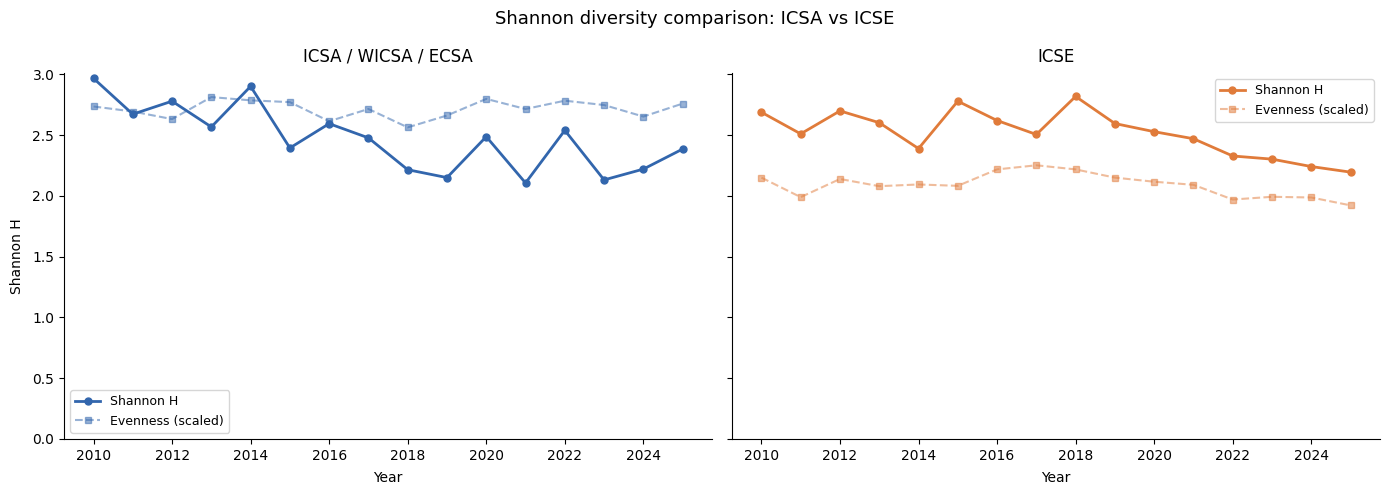

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, div_df) in zip(axes, [
    ("ICSA / WICSA / ECSA", div_icsa),
    ("ICSE",                div_icse),
]):
    conf_color = next(c["color"] for c in CONFERENCES if c["label"] == label)
    years = div_df.index.tolist()
    ax.plot(years, div_df["shannon_H"], "o-",
            color=conf_color, lw=2, ms=5, label="Shannon H")
    ax.plot(years, div_df["evenness"] * div_df["shannon_H"].max(),
            "s--", color=conf_color, lw=1.5, ms=4, alpha=0.5, label="Evenness (scaled)")
    ax.set_title(label, pad=8)
    ax.set_xticks(years[::2])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    style_ax(ax)

axes[0].set_ylabel("Shannon H", labelpad=6)
fig.suptitle("Shannon diversity comparison: ICSA vs ICSE", fontsize=13)
plt.tight_layout()
save_fig(fig, "fig_sidebyside_shannon.png")
plt.show()

## Side-by-side regional share

Saved → fig_sidebyside_regions.png


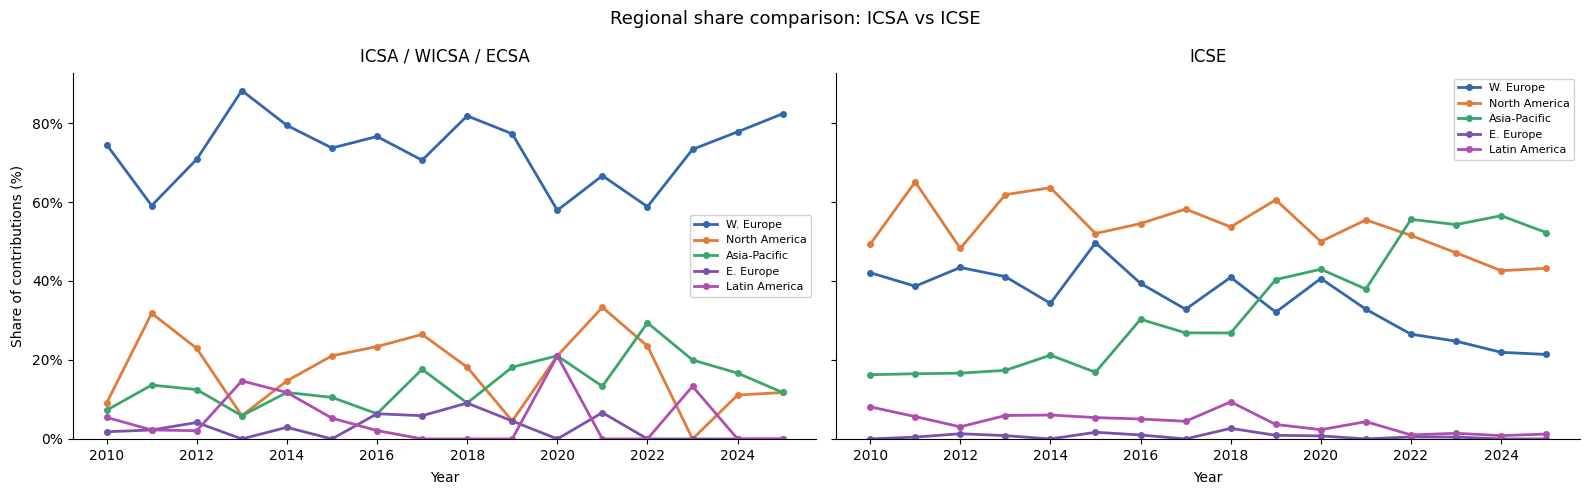

In [5]:
# only plot regions that appear in at least one conference
all_regions = [r for r in REGION_ORDER
               if r in pct_icsa.columns or r in pct_icse.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (label, pct) in zip(axes, [
    ("ICSA / WICSA / ECSA", pct_icsa),
    ("ICSE",                pct_icse),
]):
    for region in all_regions:
        if region not in pct.columns:
            continue
        if pct[region].max() < 1:
            continue  # skip negligible regions
        ax.plot(pct.index, pct[region], "o-",
                color=REGION_COLORS.get(region, "#333"),
                lw=2, ms=4, label=region)
    ax.set_title(label, pad=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xticks(pct.index[::2])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, framealpha=0.9)
    style_ax(ax)

axes[0].set_ylabel("Share of contributions (%)", labelpad=6)
fig.suptitle("Regional share comparison: ICSA vs ICSE", fontsize=13)
plt.tight_layout()
save_fig(fig, "fig_sidebyside_regions.png")
plt.show()

## HHI comparison

Saved → fig_hhi_comparison.png


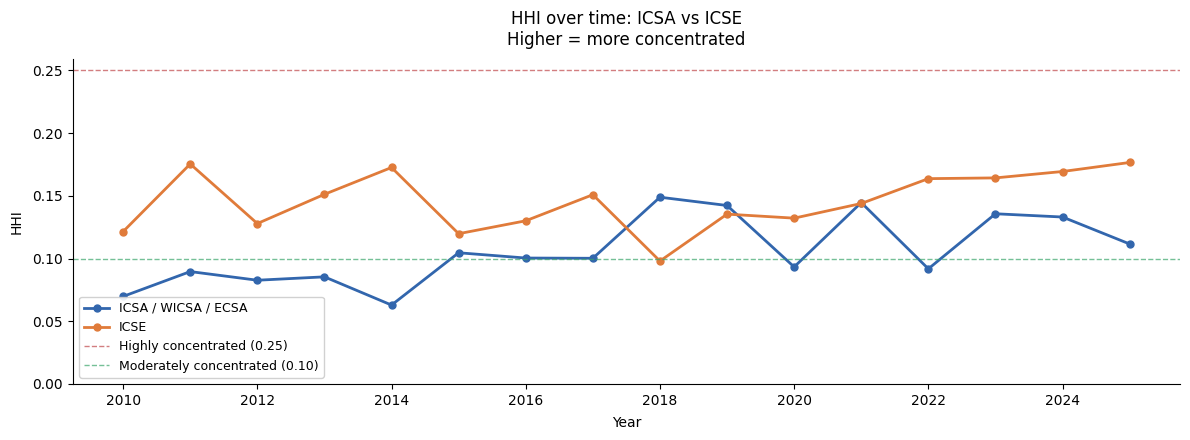

In [7]:
def compute_hhi(df):
    rows = []
    for year, g in df.groupby("year"):
        cc_counts = (
            g.drop_duplicates(subset=["doi", "country_code"])
             .groupby("country_code")["doi"].nunique()
        )
        p = cc_counts / cc_counts.sum()  # normalize by total country contributions
        rows.append({"year": year, "hhi": round(float((p ** 2).sum()), 4)})
    return pd.DataFrame(rows).set_index("year")

hhi_icsa = compute_hhi(df_icsa)
hhi_icse = compute_hhi(df_icse)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(hhi_icsa.index, hhi_icsa["hhi"], "o-",
        color="#3266ad", lw=2, ms=5, label="ICSA / WICSA / ECSA")
ax.plot(hhi_icse.index, hhi_icse["hhi"], "o-",
        color="#e07b3a", lw=2, ms=5, label="ICSE")
ax.axhline(0.25, color="#c0474a", lw=1, linestyle="--", alpha=0.7,
           label="Highly concentrated (0.25)")
ax.axhline(0.10, color="#3aa66b", lw=1, linestyle="--", alpha=0.7,
           label="Moderately concentrated (0.10)")
ax.set_ylabel("HHI", labelpad=6)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, framealpha=0.9)
ax.set_title("HHI over time: ICSA vs ICSE\nHigher = more concentrated", pad=10)
style_ax(ax)
plt.tight_layout()
save_fig(fig, "fig_hhi_comparison.png")
plt.show()